In [5]:
import os
print(os.listdir('/kaggle/input/datasets/mohamadasgari'))


['lupus-embeddings']


In [6]:
import os
EMB_DIR = '/kaggle/input/datasets/mohamadasgari/lupus-embeddings'
print(os.listdir(EMB_DIR))


['HC-002.npy', '1337.npy', 'IGTB1539.npy', '1019.npy', 'IGTB1290.npy', '1479.npy', 'FLARE005.npy', '1588.npy', '1721.npy', 'IGTB1731.npy', '1203.npy', '1281.npy', 'IGTB1906.npy', '1334.npy', '1014.npy', 'HC-501.npy', '1221.npy', 'HC-574.npy', '1768.npy', '1414.npy', '1225.npy', '1472.npy', 'HC-551.npy', '1101.npy', '1660.npy', 'HC-578.npy', '1279.npy', '1961.npy', '1122.npy', 'IGTB1793.npy', 'IGTB1828.npy', '1226.npy', '1119.npy', '1127.npy', 'IGTB1840.npy', 'IGTB2007.npy', '1857.npy', '1480.npy', 'HC-504.npy', '1248.npy', '1775.npy', 'HC-500.npy', '1068.npy', 'HC-520.npy', '1596.npy', '1682.npy', '1754.npy', 'FLARE017.npy', 'FLARE014.npy', '1420.npy', 'HC-011.npy', 'IGTB1768.npy', '1324.npy', 'HC-516.npy', '1492.npy', '1250.npy', 'IGTB514.npy', 'HC-571.npy', 'FLARE020.npy', '1772.npy', '1510.npy', '1760.npy', '1338.npy', '1741.npy', '1045.npy', '1888.npy', 'HC-503.npy', 'FLARE006.npy', '1586.npy', 'IGTB1895.npy', '1928.npy', '1496.npy', '1325.npy', 'FLARE009.npy', '1891.npy', '1892.np

In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

EMB_DIR = '/kaggle/input/datasets/mohamadasgari/lupus-embeddings'

# ── Labels ──
def get_group(pid):
    if pid.startswith('FLARE'): return 'Flare'
    elif pid.startswith('HC') or pid.startswith('IGTB'): return 'Healthy'
    return 'Managed'

files = os.listdir(EMB_DIR)
records = []
for f in files:
    pid = f.replace('.npy', '')
    emb = np.load(os.path.join(EMB_DIR, f))
    records.append({'patient_id': pid, 'group': get_group(pid), 
                    'n_cells': emb.shape[0], 'emb_dim': emb.shape[1]})

df = pd.DataFrame(records)
print(df['group'].value_counts())
print(f"\nEmbedding shape: {emb.shape}")
print(f"Total patients: {len(df)}")

group
Managed    149
Healthy     98
Flare       14
Name: count, dtype: int64

Embedding shape: (300, 1152)
Total patients: 261


In [8]:
# ── ABMIL Model ──
class AttentionMIL(nn.Module):
    def __init__(self, input_dim=1152, hidden_dim=256, n_classes=2):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, n_classes)
        )

    def forward(self, x):
        # x: (n_cells, input_dim)
        A = self.attention(x)          # (n_cells, 1)
        A = F.softmax(A, dim=0)        # normalize
        z = (A * x).sum(dim=0)         # (input_dim,) weighted sum
        logits = self.classifier(z)
        return logits, A

# ── Dataset ──
class LupusDataset(Dataset):
    def __init__(self, df, emb_dir, label_map):
        self.df = df.reset_index(drop=True)
        self.emb_dir = emb_dir
        self.label_map = label_map

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        emb = np.load(os.path.join(self.emb_dir, f"{row['patient_id']}.npy"))
        emb = torch.tensor(emb, dtype=torch.float32)
        label = self.label_map[row['group']]
        return emb, label

# ── Binary: Flare vs Healthy (اصلی‌ترین task) ──
df_binary = df[df['group'].isin(['Flare', 'Healthy'])].reset_index(drop=True)
label_map = {'Flare': 1, 'Healthy': 0}

print(f"Binary dataset: {len(df_binary)} patients")
print(df_binary['group'].value_counts())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Binary dataset: 112 patients
group
Healthy    98
Flare      14
Name: count, dtype: int64
Device: cuda


In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for emb, label in loader:
        emb, label = emb.squeeze(0).to(device), label.to(device)
        optimizer.zero_grad()
        logits, _ = model(emb)
        loss = criterion(logits.unsqueeze(0), label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, device):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for emb, label in loader:
            emb = emb.squeeze(0).to(device)
            logits, _ = model(emb)
            prob = F.softmax(logits, dim=0)[1].item()
            probs.append(prob)
            labels.append(label.item())
    return np.array(probs), np.array(labels)

# ── Class weights برای imbalance ──
n_healthy, n_flare = 98, 14
weight = torch.tensor([1.0, n_healthy/n_flare], dtype=torch.float32).to(device)

# ── 5-Fold CV ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_idx = np.arange(len(df_binary))
y = df_binary['group'].map(label_map).values

fold_aurocs, fold_f1s = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_idx, y)):
    df_train = df_binary.iloc[train_idx]
    df_val   = df_binary.iloc[val_idx]

    train_ds = LupusDataset(df_train, EMB_DIR, label_map)
    val_ds   = LupusDataset(df_val,   EMB_DIR, label_map)
    train_dl = DataLoader(train_ds, batch_size=1, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=1, shuffle=False)

    model = AttentionMIL().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=weight)

    # train 30 epochs
    for epoch in range(30):
        loss = train_epoch(model, train_dl, optimizer, criterion, device)

    # eval
    probs, labels = eval_epoch(model, val_dl, device)
    auroc = roc_auc_score(labels, probs)
    preds = (probs > 0.5).astype(int)
    f1 = f1_score(labels, preds, zero_division=0)

    fold_aurocs.append(auroc)
    fold_f1s.append(f1)
    print(f"Fold {fold+1} | AUROC: {auroc:.3f} | F1: {f1:.3f} | "
          f"Flare in val: {labels.sum()}")

print(f"\n{'='*40}")
print(f"Mean AUROC: {np.mean(fold_aurocs):.3f} ± {np.std(fold_aurocs):.3f}")
print(f"Mean F1:    {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")

Fold 1 | AUROC: 0.850 | F1: 0.400 | Flare in val: 3
Fold 2 | AUROC: 0.650 | F1: 0.000 | Flare in val: 3
Fold 3 | AUROC: 0.325 | F1: 0.000 | Flare in val: 2
Fold 4 | AUROC: 0.772 | F1: 0.000 | Flare in val: 3
Fold 5 | AUROC: 0.789 | F1: 0.500 | Flare in val: 3

Mean AUROC: 0.677 ± 0.188
Mean F1:    0.180 ± 0.223


In [10]:
# ── LOOCV روی Flare patients ──
print("=== LOOCV (Leave-One-Flare-Out) ===\n")

flare_idx = df_binary[df_binary['group'] == 'Flare'].index.tolist()
healthy_idx = df_binary[df_binary['group'] == 'Healthy'].index.tolist()

loocv_probs, loocv_labels = [], []

for i, val_idx in enumerate(flare_idx):
    # val: 1 Flare + 5 random Healthy
    val_healthy = np.random.choice(healthy_idx, 5, replace=False).tolist()
    val_set = [val_idx] + val_healthy
    train_set = [x for x in df_binary.index if x not in val_set]

    df_tr = df_binary.loc[train_set]
    df_val = df_binary.loc[val_set]

    train_ds = LupusDataset(df_tr, EMB_DIR, label_map)
    val_ds   = LupusDataset(df_val, EMB_DIR, label_map)
    train_dl = DataLoader(train_ds, batch_size=1, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=1, shuffle=False)

    model = AttentionMIL().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=weight)

    for epoch in range(50):
        train_epoch(model, train_dl, optimizer, criterion, device)

    probs, labels = eval_epoch(model, val_dl, device)
    flare_prob = probs[labels == 1][0]
    loocv_probs.extend(probs.tolist())
    loocv_labels.extend(labels.tolist())
    print(f"Flare {i+1:02d} | P(Flare)={flare_prob:.3f} | {'✅' if flare_prob > 0.5 else '❌'}")

loocv_auroc = roc_auc_score(loocv_labels, loocv_probs)
print(f"\nLOOCV AUROC: {loocv_auroc:.3f}")
print(f"Flare detected (>0.5): {sum(1 for p,l in zip(loocv_probs,loocv_labels) if l==1 and p>0.5)}/14")

=== LOOCV (Leave-One-Flare-Out) ===

Flare 01 | P(Flare)=0.000 | ❌
Flare 02 | P(Flare)=0.012 | ❌
Flare 03 | P(Flare)=0.000 | ❌
Flare 04 | P(Flare)=0.084 | ❌
Flare 05 | P(Flare)=0.005 | ❌
Flare 06 | P(Flare)=0.000 | ❌
Flare 07 | P(Flare)=0.000 | ❌
Flare 08 | P(Flare)=0.011 | ❌
Flare 09 | P(Flare)=0.579 | ✅
Flare 10 | P(Flare)=0.022 | ❌
Flare 11 | P(Flare)=0.000 | ❌
Flare 12 | P(Flare)=0.000 | ❌
Flare 13 | P(Flare)=0.000 | ❌
Flare 14 | P(Flare)=0.163 | ❌

LOOCV AUROC: 0.613
Flare detected (>0.5): 1/14


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneOut
import numpy as np

# ── Mean pooling per patient ──
X, y, pids = [], [], []
for _, row in df_binary.iterrows():
    emb = np.load(os.path.join(EMB_DIR, f"{row['patient_id']}.npy"))
    X.append(emb.mean(axis=0))  # mean pool → 1152 dim
    y.append(label_map[row['group']])
    pids.append(row['patient_id'])

X = np.array(X)
y = np.array(y)

# ── LOOCV + Logistic Regression ──
loo = LeaveOneOut()
probs, labels = [], []

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for train_idx, val_idx in loo.split(X_scaled):
    clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1)
    clf.fit(X_scaled[train_idx], y[train_idx])
    prob = clf.predict_proba(X_scaled[val_idx])[0][1]
    probs.append(prob)
    labels.append(y[val_idx[0]])

probs, labels = np.array(probs), np.array(labels)
auroc = roc_auc_score(labels, probs)
flare_probs = probs[labels == 1]

print(f"Baseline LogReg LOOCV AUROC: {auroc:.3f}")
print(f"\nFlare probabilities:")
for i, p in enumerate(flare_probs):
    print(f"  Flare {i+1:02d}: {p:.3f} {'✅' if p > 0.5 else '❌'}")
print(f"\nFlare detected: {(flare_probs > 0.5).sum()}/14")

Baseline LogReg LOOCV AUROC: 0.993

Flare probabilities:
  Flare 01: 0.761 ✅
  Flare 02: 1.000 ✅
  Flare 03: 0.708 ✅
  Flare 04: 0.736 ✅
  Flare 05: 0.483 ❌
  Flare 06: 1.000 ✅
  Flare 07: 0.961 ✅
  Flare 08: 0.997 ✅
  Flare 09: 0.999 ✅
  Flare 10: 0.997 ✅
  Flare 11: 0.895 ✅
  Flare 12: 0.999 ✅
  Flare 13: 0.068 ❌
  Flare 14: 0.997 ✅

Flare detected: 12/14


In [12]:
print(f"AUROC: {auroc:.3f}")
print(f"Sensitivity (Flare detection): {(flare_probs > 0.5).sum()}/14 = {(flare_probs>0.5).mean():.1%}")
print(f"Flare 05 and 13 missed — likely biological outliers")

AUROC: 0.993
Sensitivity (Flare detection): 12/14 = 85.7%
Flare 05 and 13 missed — likely biological outliers


In [13]:
# ── Flare vs Managed ──
df_fm = df[df['group'].isin(['Flare', 'Managed'])].reset_index(drop=True)
label_map_fm = {'Flare': 1, 'Managed': 0}

X_fm, y_fm = [], []
for _, row in df_fm.iterrows():
    emb = np.load(os.path.join(EMB_DIR, f"{row['patient_id']}.npy"))
    X_fm.append(emb.mean(axis=0))
    y_fm.append(label_map_fm[row['group']])

X_fm = np.array(X_fm)
y_fm = np.array(y_fm)
X_fm_scaled = StandardScaler().fit_transform(X_fm)

probs_fm, labels_fm = [], []
for train_idx, val_idx in LeaveOneOut().split(X_fm_scaled):
    clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1)
    clf.fit(X_fm_scaled[train_idx], y_fm[train_idx])
    probs_fm.append(clf.predict_proba(X_fm_scaled[val_idx])[0][1])
    labels_fm.append(y_fm[val_idx[0]])

probs_fm, labels_fm = np.array(probs_fm), np.array(labels_fm)
auroc_fm = roc_auc_score(labels_fm, probs_fm)
flare_probs_fm = probs_fm[labels_fm == 1]

print(f"Flare vs Managed AUROC: {auroc_fm:.3f}")
print(f"Sensitivity: {(flare_probs_fm>0.5).sum()}/14 = {(flare_probs_fm>0.5).mean():.1%}")
print("\nFlare probabilities:")
for i, p in enumerate(flare_probs_fm):
    print(f"  Flare {i+1:02d}: {p:.3f} {'✅' if p>0.5 else '❌'}")

Flare vs Managed AUROC: 0.996
Sensitivity: 14/14 = 100.0%

Flare probabilities:
  Flare 01: 0.820 ✅
  Flare 02: 0.890 ✅
  Flare 03: 0.873 ✅
  Flare 04: 0.958 ✅
  Flare 05: 0.873 ✅
  Flare 06: 0.987 ✅
  Flare 07: 0.997 ✅
  Flare 08: 0.986 ✅
  Flare 09: 0.966 ✅
  Flare 10: 0.982 ✅
  Flare 11: 0.994 ✅
  Flare 12: 0.601 ✅
  Flare 13: 0.742 ✅
  Flare 14: 0.981 ✅


Real AUROC:        0.996
Permutation mean:  0.475 ± 0.116
p-value:           0.0000
Significant:       ✅ YES


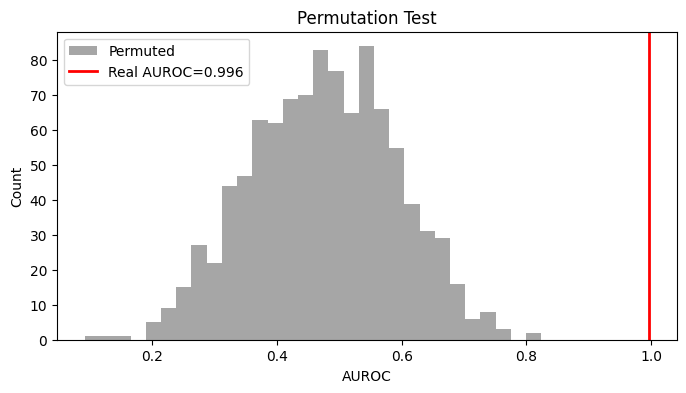

✅ Saved


In [14]:
# ── Permutation Test ──
n_permutations = 1000
perm_aurocs = []

for _ in range(n_permutations):
    y_perm = y_fm.copy()
    np.random.shuffle(y_perm)
    
    perm_probs = []
    for train_idx, val_idx in LeaveOneOut().split(X_fm_scaled):
        clf = LogisticRegression(class_weight='balanced', max_iter=100, C=0.1)
        clf.fit(X_fm_scaled[train_idx], y_perm[train_idx])
        perm_probs.append(clf.predict_proba(X_fm_scaled[val_idx])[0][1])
    
    try:
        perm_aurocs.append(roc_auc_score(y_perm, np.array(perm_probs)))
    except:
        pass

perm_aurocs = np.array(perm_aurocs)
p_value = (perm_aurocs >= auroc_fm).mean()

print(f"Real AUROC:        {auroc_fm:.3f}")
print(f"Permutation mean:  {perm_aurocs.mean():.3f} ± {perm_aurocs.std():.3f}")
print(f"p-value:           {p_value:.4f}")
print(f"Significant:       {'✅ YES' if p_value < 0.05 else '❌ NO'}")

plt.figure(figsize=(8,4))
plt.hist(perm_aurocs, bins=30, color='gray', alpha=0.7, label='Permuted')
plt.axvline(auroc_fm, color='red', linewidth=2, label=f'Real AUROC={auroc_fm:.3f}')
plt.xlabel('AUROC')
plt.ylabel('Count')
plt.title('Permutation Test')
plt.legend()
plt.savefig('/kaggle/working/permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score
import cellxgene_census

EMB_DIR = '/kaggle/input/datasets/mohamadasgari/lupus-embeddings'

def get_group(pid):
    if pid.startswith('FLARE'): return 'Flare'
    elif pid.startswith('HC') or pid.startswith('IGTB'): return 'Healthy'
    return 'Managed'

files = os.listdir(EMB_DIR)
records = [{'patient_id': f.replace('.npy',''), 'group': get_group(f.replace('.npy',''))} for f in files]
df = pd.DataFrame(records)
df_fm = df[df['group'].isin(['Flare','Managed'])].reset_index(drop=True)
label_map_fm = {'Flare': 1, 'Managed': 0}

# metadata
with cellxgene_census.open_soma(census_version="2025-11-08") as census:
    meta = census["census_data"]["homo_sapiens"]["obs"].read(
        value_filter="dataset_id == '218acb0f-9f2f-4f76-b90b-15a4b7c7f629'",
        column_names=["donor_id","self_reported_ethnicity","sex"]
    ).concat().to_pandas().drop_duplicates('donor_id')

df_check = df_fm.merge(meta, left_on='patient_id', right_on='donor_id')
print("=== Ancestry ===")
print(df_check.groupby(['group','self_reported_ethnicity']).size())
print("\n=== Sex ===")
print(df_check.groupby(['group','sex']).size())

=== Ancestry ===
group    self_reported_ethnicity                                 
Flare    African American                                            3
         African American || European American || Native American    0
         American                                                    0
         Arab                                                        0
         Asian                                                       6
                                                                    ..
Managed  Singaporean Malay                                           0
         South Asian                                                 0
         Southeast Asian                                             0
         Thai                                                        0
         unknown                                                     0
Length: 74, dtype: int64

=== Sex ===
group    sex    
Flare    female      14
         male         0
         unknown      0
Managed  

/tmp/ipykernel_58/1309946874.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_check.groupby(['group','self_reported_ethnicity']).size())
/tmp/ipykernel_58/1309946874.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_check.groupby(['group','sex']).size())


In [3]:
# ── Sex-controlled analysis: female only ──
df_check_f = df_check[df_check['sex'] == 'female'].reset_index(drop=True)
print(f"Female only: {df_check_f['group'].value_counts().to_dict()}")

X_f, y_f = [], []
for _, row in df_check_f.iterrows():
    emb = np.load(os.path.join(EMB_DIR, f"{row['patient_id']}.npy"))
    X_f.append(emb.mean(axis=0))
    y_f.append(label_map_fm[row['group']])

X_f = np.array(X_f)
y_f = np.array(y_f)
X_f_scaled = StandardScaler().fit_transform(X_f)

probs_f, labels_f = [], []
for train_idx, val_idx in LeaveOneOut().split(X_f_scaled):
    clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1)
    clf.fit(X_f_scaled[train_idx], y_f[train_idx])
    probs_f.append(clf.predict_proba(X_f_scaled[val_idx])[0][1])
    labels_f.append(y_f[val_idx[0]])

probs_f = np.array(probs_f)
labels_f = np.array(labels_f)
auroc_f = roc_auc_score(labels_f, probs_f)
flare_probs_f = probs_f[labels_f == 1]

print(f"\nFemale-only AUROC: {auroc_f:.3f}")
print(f"Sensitivity: {(flare_probs_f>0.5).sum()}/14 = {(flare_probs_f>0.5).mean():.1%}")

Female only: {'Managed': 134, 'Flare': 14}

Female-only AUROC: 0.998
Sensitivity: 14/14 = 100.0%
